In [46]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numpy.linalg as LA
import scipy.constants as const
from scipy.spatial.transform import Rotation

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib ipympl


import sys
sys.path.append('../src')
import satellites as sat
import stateest as se
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import matplotlib as mpl

mpl.rcParams.update({
    # figure
    'figure.figsize':       [8, 6],
    'figure.dpi':           150,
    'figure.facecolor':     'white',

    # axes
    'axes.titlesize':       14,
    'axes.labelsize':       12,
    'axes.linewidth':       1.0,
    'axes.grid':            True,
    'axes.spines.top':      True,
    'axes.spines.right':    True,

    # grid
    'grid.linestyle':       '-',
    'grid.linewidth':       0.5,
    'grid.alpha':           0.75,

    # lines
    'lines.linewidth':      1.5,
    'lines.markersize':     6,

    # ticks
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'xtick.direction':      'in',
    'ytick.direction':      'in',

    # legend
    'legend.fontsize':      10,
    'legend.frameon':       True,
    'legend.framealpha':    0.8,

    # font
    'font.family':          'sans-serif',
    'font.size':            11,

    # saving
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    'white',
})

# Orbit Simulation

In [170]:
SIM_TIME_DELTA_S = 29.11

XHAT  = np.reshape( [1,0,0], [1,3])
YHAT  = np.reshape( [0,1,0], [1,3])
ZHAT  = np.reshape( [0,0,1], [1,3])

dist1 = sat.EARTH_RADIUS_M + 1000
vel1 = 7904.76692
mass1 = 100

nobjects = 13
rng = np.random.default_rng( seed = 123 )

# rdilate = 1.23 # no variation in radius
phi = 0 # no variation in longitude
rmin = 1
rmax = 1.3
# rdilate = rng.uniform(1, 1.13, [nobjects,1])
rdilate = np.linspace(rmin, rmax, nobjects).reshape([nobjects,1])
# phi = const.pi * rng.uniform(0, 2, [nobjects,1])
# theta = 1.0*const.pi/2 * np.ones([nobjects, 1])
theta = const.pi * np.linspace(0.45, 0.5, nobjects).reshape([nobjects,1])
# theta = const.pi * rng.uniform(0.45, 0.5, [nobjects,1])
# velang = np.deg2rad( rng.uniform( 0, 3, [nobjects,1] ))
velang = np.deg2rad([0]*nobjects)

rvec = rdilate * (
    np.cos(phi)*np.sin(theta)*XHAT
    + np.sin(phi)*np.sin(theta)*YHAT
    + np.cos(theta)*ZHAT
    )
thvec = (
    -np.sin(phi)*np.sin(theta)*XHAT
    + np.cos(phi)*np.sin(theta)*YHAT
    + np.cos(theta)*ZHAT
    )

orbit_objects = []
for r,th,va in zip(rvec, thvec, velang):
    rot = Rotation.from_rotvec( va * ZHAT )
    orbit_objects.append(
        sat.GravityObject( 
            xyz_m = dist1 * r,
            vxyz_mps = rot.as_matrix() @ (vel1*th),
            mass_kg=mass1
        )
    )

esys = sat.EarthSystem( j2_correction=True, delta_time_s=SIM_TIME_DELTA_S )
for s in orbit_objects:
    esys.add_object( s )

esys.init_snapshots( n_time_steps=2 )


N_TIME_STEPS = 100
for i in range(N_TIME_STEPS):
    esys.propagate_step()
    
r = np.stack(esys.positions)
v = np.stack(esys.velocities)
a = np.stack(esys.accels)


## plots

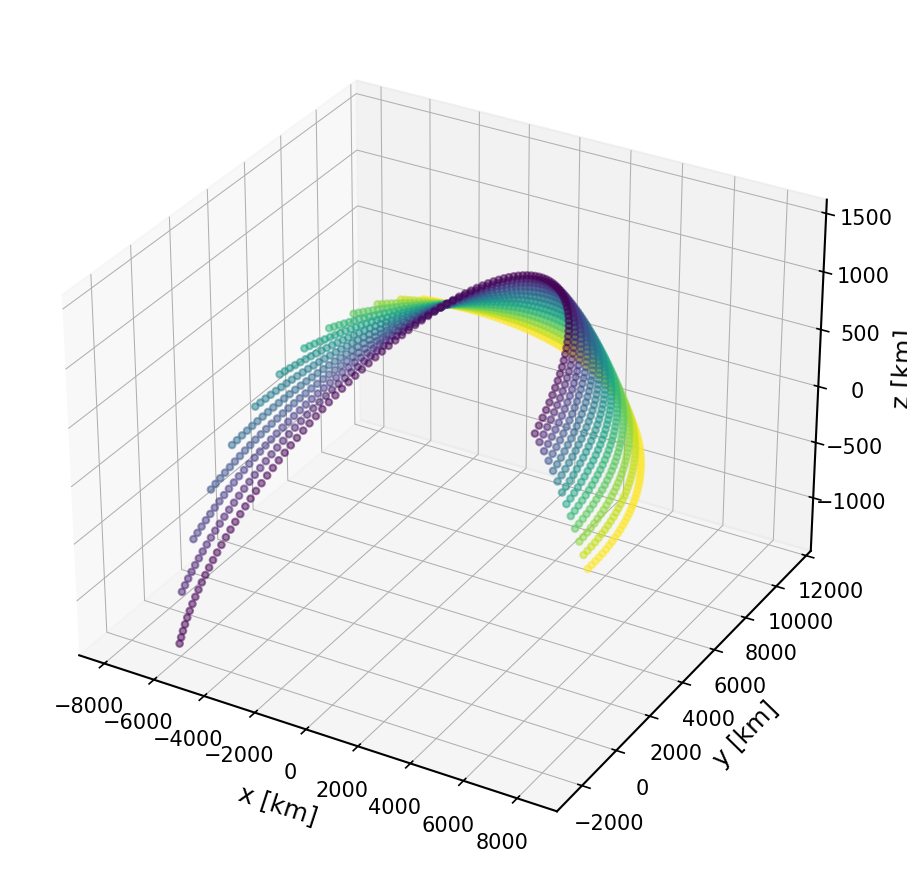

In [171]:
ls = {
    # 'cmap': 'viridis',
    's': 10,           # marker size
    'alpha': 0.5,      # transparency
    'depthshade': True, # shade markers by depth
    
}

timevec = esys.delta_time_s * np.arange(N_TIME_STEPS+2)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
npts_step = 1
cmap = plt.colormaps['viridis']
def color_fun(r, rmin, rmax):
    return cmap((r-rmin)/(rmax-rmin))

for i in range(0,nobjects, 1):
    x = r[::npts_step,i,0] / const.kilo
    y = r[::npts_step,i,1] / const.kilo
    z = r[::npts_step,i,2] / const.kilo
    # ax.scatter(x,y,z,c=timevec[::npts_step], **ls)
    # ax.scatter(x,y,z,c=color_fun(rdilate[i], rmin, rmax), **ls)
    ax.scatter(x,y,z,c=color_fun(theta[i], theta.min(), theta.max()), **ls)


axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'x [km]',
    'ylabel': 'y [km]',
    'zlabel': 'z [km]',
}
ax.set(**axkwargs)
plt.tight_layout()
plt.show()

In [281]:
plt.close('all')

# Measurement

In [174]:
from measurement import Position
mus = np.zeros(3)
# covs = np.diag(3*[1])
covs = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
])*300
pos_meas = Position(noise_mean=mus, noise_cov=covs, rng=2318)

nth_object = 9
r_in = r[:,nth_object,:].squeeze().T
r_meas = pos_meas.measure(r_in, state_order=0)


## plots

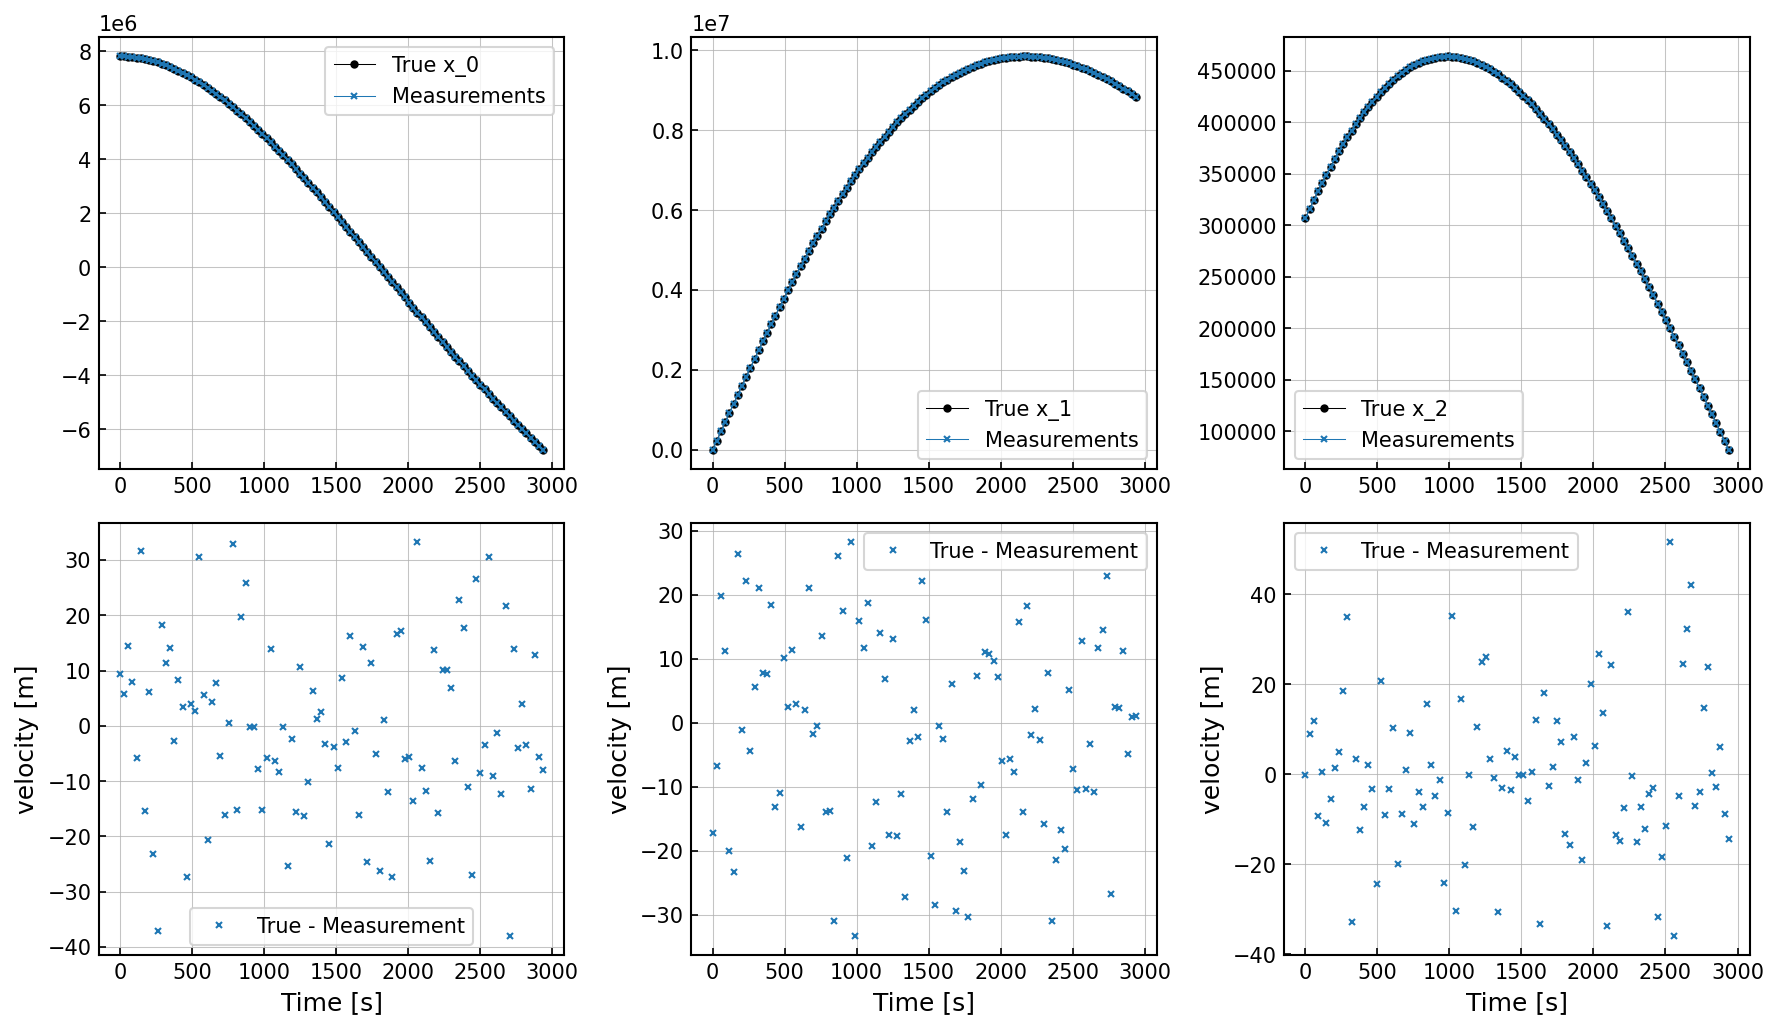

In [175]:
timevec = esys.delta_time_s * np.arange(N_TIME_STEPS+2)
fig, axs = plt.subplots(2,3, figsize=[12,7])
for i, (xi,yi) in enumerate(zip(r_in, r_meas)):
    axs[0,i].plot(timevec, xi, lw=0.5, marker='o', ms=3, color='k', label=f'True x_{i}')
    axs[0,i].plot(timevec, yi, lw=0.5, marker='x', ms=3, color='tab:blue', label='Measurements')
    
    axs[1,i].plot(timevec, xi - yi, lw=0.0, marker='x', ms=3, color='tab:blue', label='True - Measurement')
    
    
# axs[0,0].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='all states')
# axs[0,0].legend()

# axs[1,1].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,1], lw=1, marker='x', ms=5, color='tab:orange', label='all states')


axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'velocity [m]',
}
for ax in axs[1]:
    ax.set(**axkwargs)
for ax in axs:
    for ax in ax:
        # ax.grid(True)
        ax.legend()
    
plt.tight_layout()
plt.show()

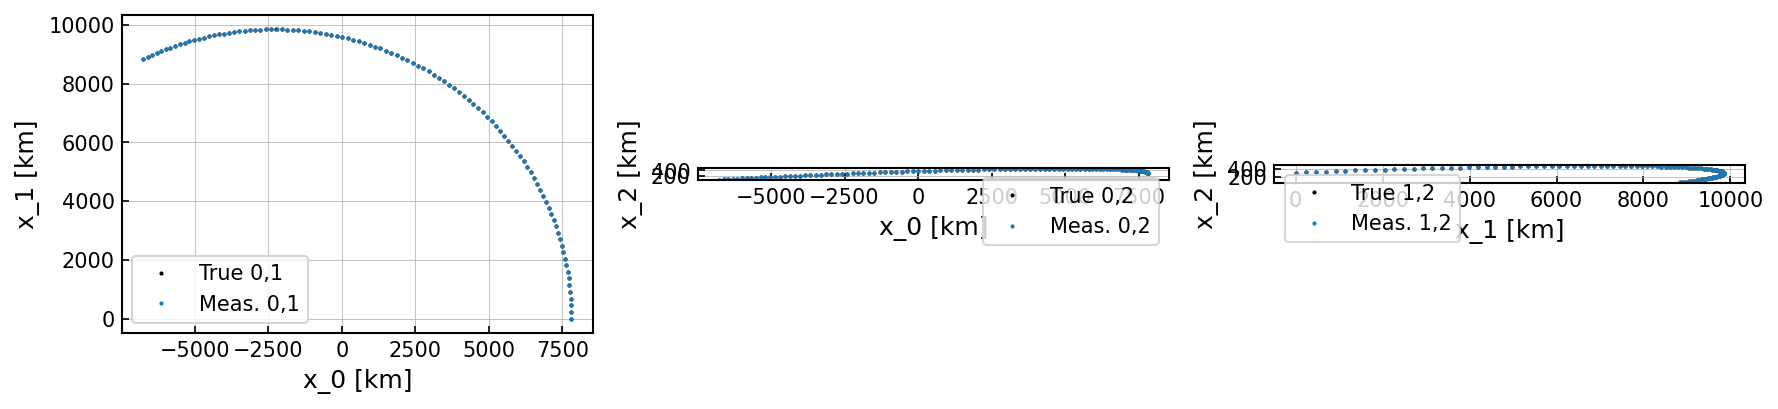

In [176]:
ls = {
    'lw':0,
    'marker':'o',
    'ms': 1,
    'alpha':1,
}
fig = plt.figure(figsize=[12, 5])
gs = gridspec.GridSpec(1, 3, figure=fig)

axs = [fig.add_subplot(gs[0, i]) for i in range(3)]
axcount = 0
dist_scale = 1/const.kilo
for i in range(3):
    for j in range(i+1, 3):
        ax = axs[axcount]
        ax.plot(dist_scale*r_in[i], dist_scale*r_in[j], **ls, color='k', label=f'True {i},{j}')
        ax.plot(dist_scale*r_meas[i], dist_scale*r_meas[j], **ls, color='tab:blue', label=f'Meas. {i},{j}')
        
        axkwargs = {
            # 'xticks': timevec[::10],
            # 'ylim': [-20, 20],
            'xlabel': f'x_{i} [km]',
            'ylabel': f'x_{j} [km]',
            'aspect': 'equal'
        }
        axcount += 1

        ax.set(**axkwargs)
        ax.legend()
    
    
plt.tight_layout()
plt.show()

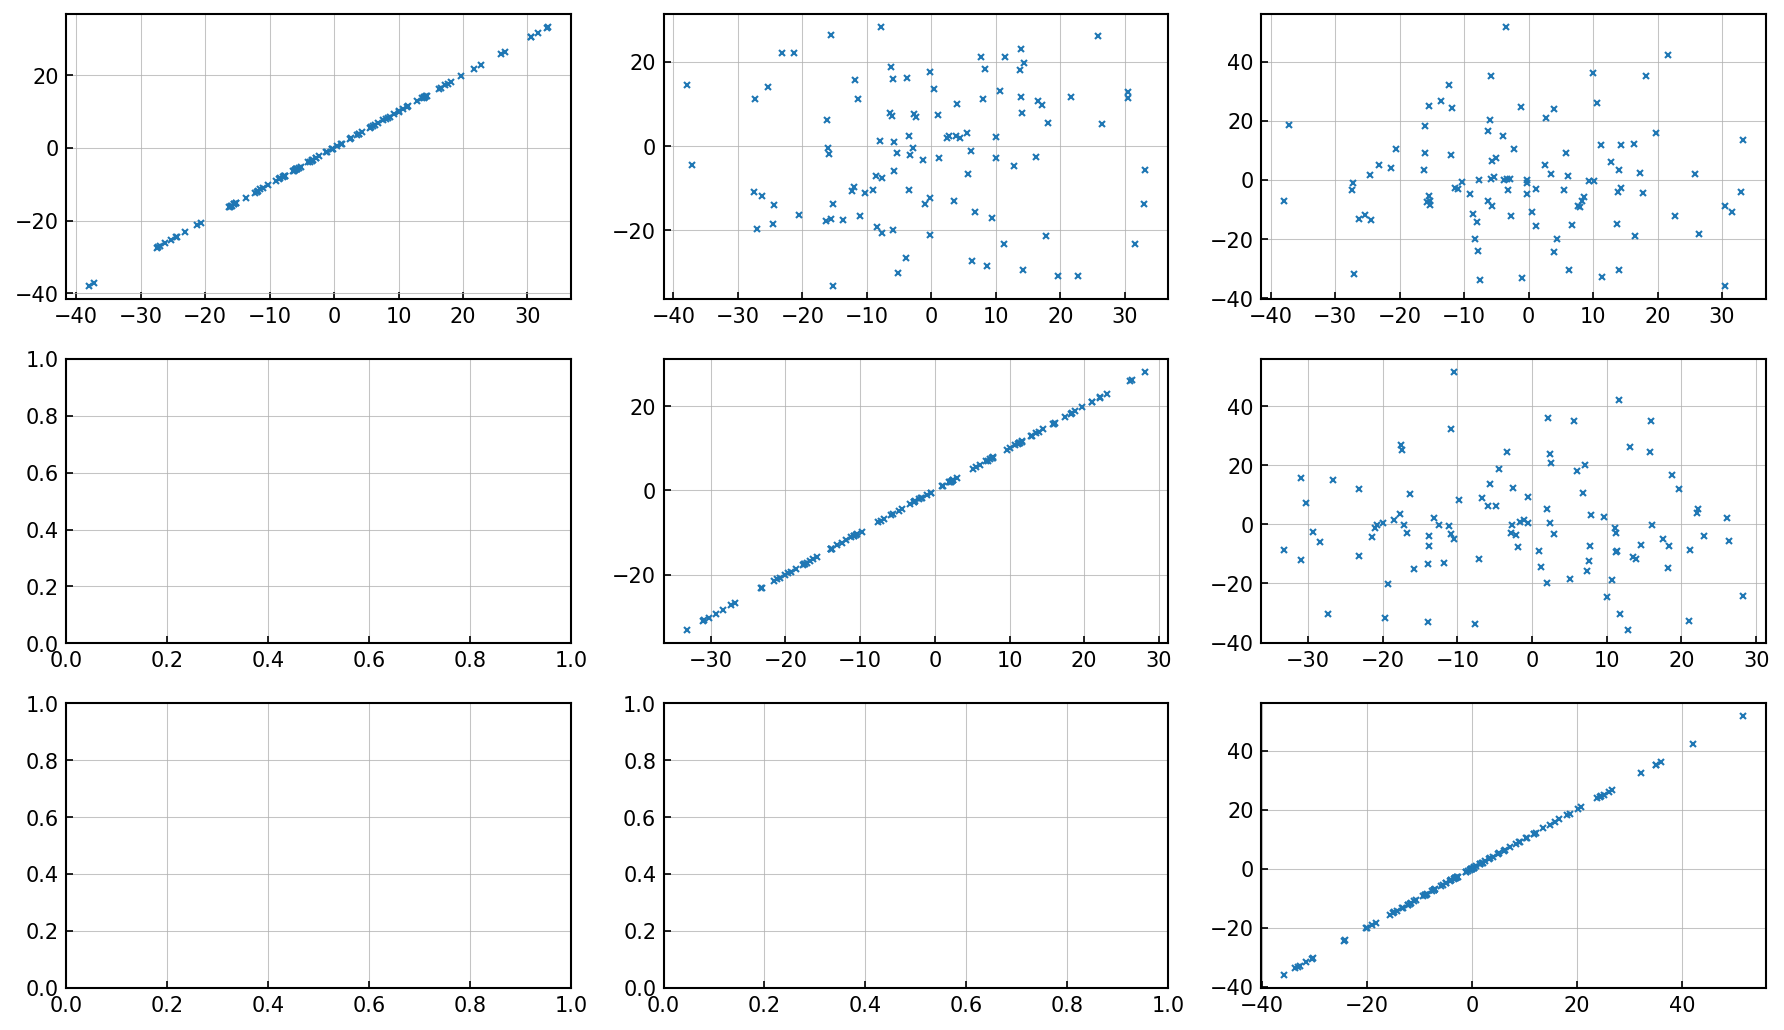

In [177]:
fig, axs = plt.subplots(3,3, figsize=[12,7])

for i in range(3):
    diffi = r_in[i] - r_meas[i]
    for j in range(i, 3):
        diffj = r_in[j] - r_meas[j]
        axs[i,j].plot(diffi, diffj, lw=0.0, marker='x', ms=3, color='tab:blue', label='True - Measurement')


        axkwargs = {
            # 'xticks': timevec[::10],
            # 'ylim': [-20, 20],
            'xlabel': f'x_{i} [km]',
            'ylabel': f'x_{j} [km]',
            'aspect': 'equal'
        }
        axcount += 1

        ax.set(**axkwargs)
        ax.legend()
        
plt.tight_layout()
plt.show()

# State estimation with Kalman Filter

In [185]:
dt = SIM_TIME_DELTA_S * 3
STATE_ORDER = 2 # constant acceleration
nstate = STATE_ORDER + 1
# state: [position, velocity, accel]       
F1 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=STATE_ORDER)
F2 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=STATE_ORDER)
F3 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=STATE_ORDER)
F = np.block([
    [F1, np.zeros(shape=[nstate, nstate + nstate])],
    [np.zeros(shape=[nstate, nstate]), F2, np.zeros(shape=[nstate, nstate]) ],
    [np.zeros(shape=[nstate, nstate + nstate]), F3],
])
for row in F:
    print([f'{fij:9.3f}' for fij in row])

['    1.000', '   87.330', ' 3813.264', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000']
['    0.000', '    1.000', '   87.330', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000']
['    0.000', '    0.000', '    1.000', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000']
['    0.000', '    0.000', '    0.000', '    1.000', '   87.330', ' 3813.264', '    0.000', '    0.000', '    0.000']
['    0.000', '    0.000', '    0.000', '    0.000', '    1.000', '   87.330', '    0.000', '    0.000', '    0.000']
['    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    1.000', '    0.000', '    0.000', '    0.000']
['    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    1.000', '   87.330', ' 3813.264']
['    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    0.000', '    1.000', '   87.330']
['    0.000', '    0.000', '    0.000', '    0.000', '  

In [45]:
r_meas.shape

(3, 302)

In [217]:
N_DIMS = 3
# measurement process (state to measurement)
H = np.zeros([3,N_DIMS*nstate])
for i in range(N_DIMS):
    H[i,i*nstate] = 1

print(H)

# process noise
Q = 1 * np.eye(N_DIMS*nstate)
# measurement noise
R = np.diag(np.array([1, 1, 1]))*200

# initial state
n_init = 1 # which measurement to use as initial point for model
r_est_init = r_meas[:, n_init].reshape([-1,1])
v_est_init = utils.finite_difference(r_meas[:,n_init-1:n_init+2], dt=dt, method="central")
a_est_init = utils.finite_difference_ord2(r_meas[:,n_init-1:n_init+2], dt=dt)
x0 = []
for rva in zip(r_est_init, v_est_init, a_est_init):
    for s in rva:
        x0.append(s)
        
x0 = np.array(x0)
print(x0)
print(H@x0)
# x0 = np.array([[5, 0, 0, 1, 0, 0, 1, 0, 0]])
# initial uncertainty. make high to convey broader prior
P0 = np.diag([100, 9, 25, 100, 9, 25, 100, 9, 25])      
# controls
B = np.eye(6)
u = np.zeros_like(x0)

# # init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

n_meas = r_meas.shape[1]
for i in range(n_init, n_meas):
    r_ = r_meas[:,i].reshape([-1,1])
    x_est, _ = kf.perform_epoch(u=None, z=r_, postcovkwargs={'stable':True})


print("True position:", [f"({e[0]:.2f}, {e[1]:.2f}, {e[2]:.2f})" for e in r_in.T])
print("Measured:", [f"({e[0]:.2f}, {e[1]:.2f}, {e[2]:.2f})" for e in r_meas.T])


estimates_rva = kf.get_states(which='estimates')
r_est = estimates_rva[:,::nstate].T
print("Estimates:", [f"({e[0]:.2f}, {e[1]:.2f}, {e[2]:.2f})" for e in r_est.T])
kfstates = kf.get_states(which='all')



[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]]
[[ 7.80564891e+06]
 [-6.33061565e+01]
 [-7.26051420e-01]
 [ 2.29937112e+05]
 [ 2.63221389e+03]
 [-1.27727590e-02]
 [ 3.15709963e+05]
 [ 1.00873317e+02]
 [-2.80351083e-02]]
[[7805648.91157183]
 [ 229937.11182703]
 [ 315709.96262555]]
True position: ['(7808418.17, 0.00, 306793.59)', '(7805654.66, 229930.36, 315719.00)', '(7797366.14, 459779.38, 324424.13)', '(7783565.20, 689303.35, 332899.91)', '(7764268.92, 918340.65, 341140.66)', '(7739500.82, 1146730.77, 349140.99)', '(7709290.78, 1374314.57, 356895.83)', '(7673674.92, 1600934.70, 364400.40)', '(7632695.49, 1826435.83, 371650.28)', '(7586400.67, 2050665.04, 378641.34)', '(7534844.46, 2273472.06, 385369.81)', '(7478086.47, 2494709.56, 391832.22)', '(7416191.68, 2714233.40, 398025.49)', '(7349230.27, 2931902.93, 403946.82)', '(7277277.35, 3147581.14, 409593.81)', '(7200412.74, 3361134.94, 414964.34)', '(7118720.71, 3572435.31, 420056.66)', '(70322

In [213]:
estimates_rva[:,::nstate].shape

(101, 3)

In [214]:
r_meas.shape

(3, 102)

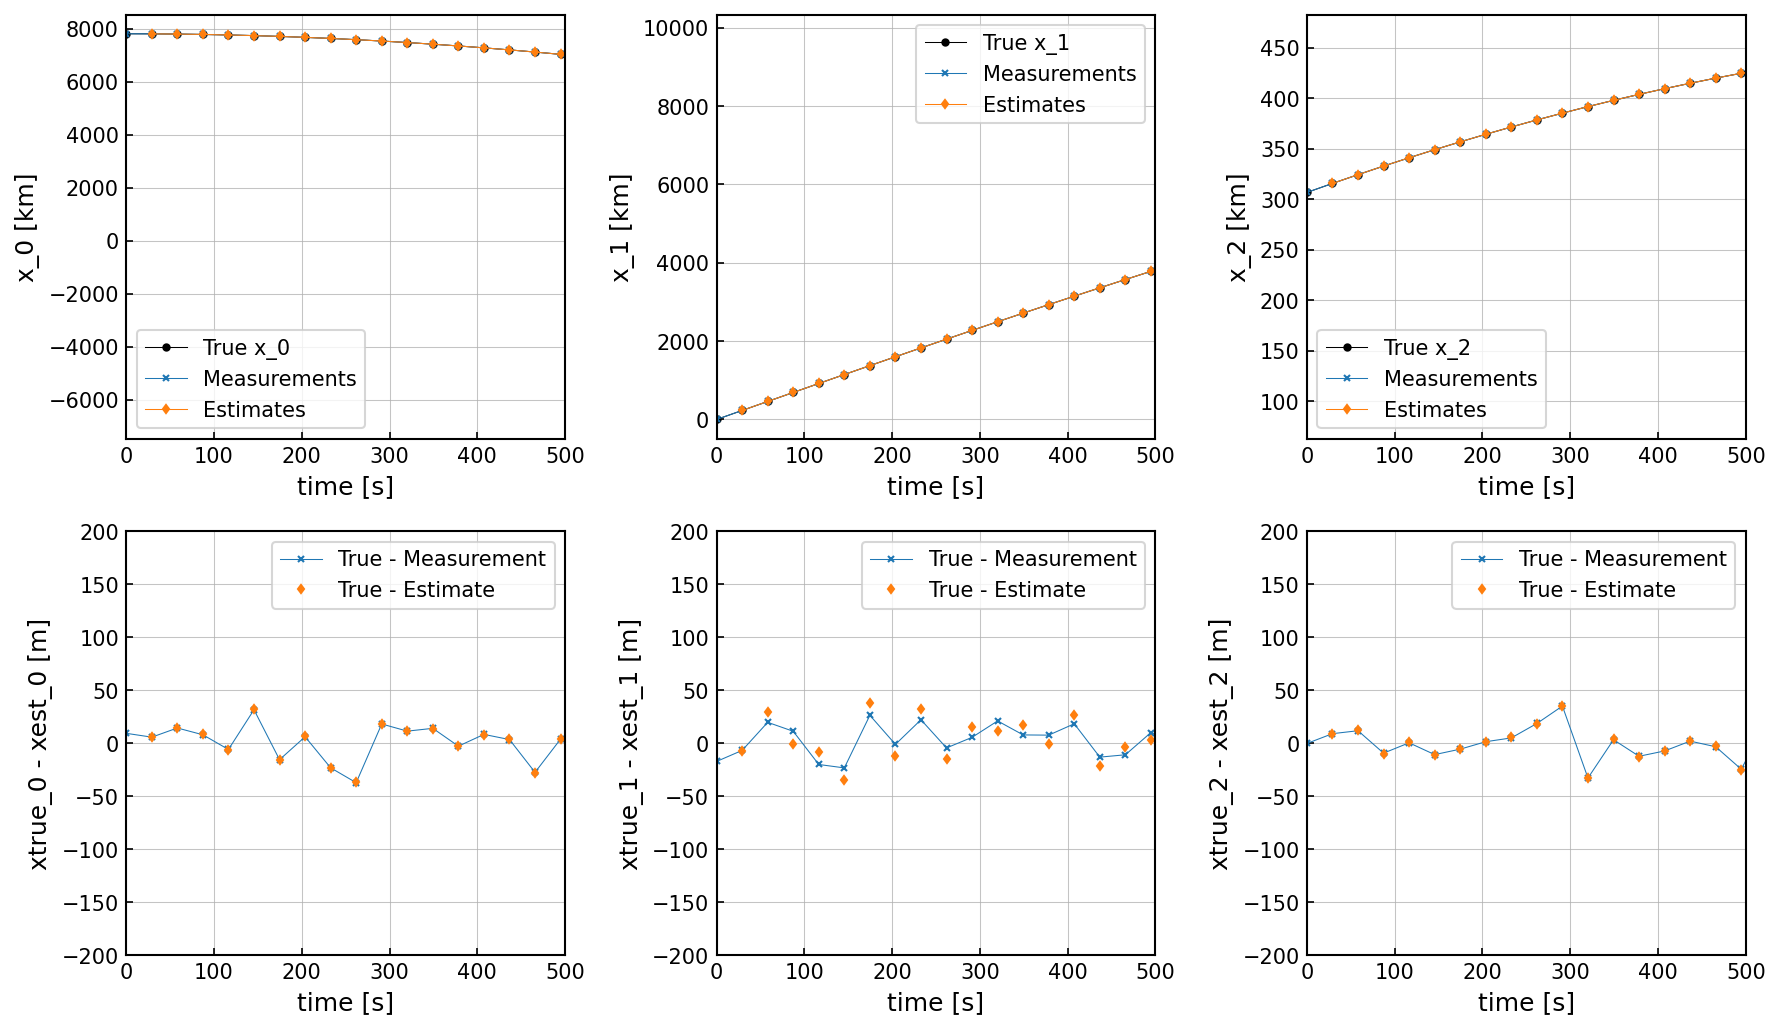

In [219]:

xlim= [0, 500]



timevec = esys.delta_time_s * np.arange(N_TIME_STEPS+2)
fig, axs = plt.subplots(2,3, figsize=[12,7])

for i, (rin_, rmeas_, rest_) in enumerate(zip(r_in, r_meas, r_est)):
    ax = axs[0,i]
    yscale = 1/const.kilo
    ax.plot(timevec, yscale*rin_, lw=0.5, marker='o', ms=3, color='k', label=f'True x_{i}')
    ax.plot(timevec, yscale*rmeas_, lw=0.5, marker='x', ms=3, color='tab:blue', label='Measurements')
    ax.plot(timevec[1:], yscale*rest_, lw=0.5, marker='d', ms=3, color='tab:orange', label='Estimates')
    
    axkwargs = {
        # 'xticks': timevec[::10],
        'xlim': xlim,
        # 'ylim': [-20, 20],
        'xlabel': 'time [s]',
        'ylabel': f'x_{i} [km]',
        # 'aspect': '10'
    }
    axcount += 1

    ax.set(**axkwargs)
    ax.legend()
    
    ax = axs[1,i]

    ax.plot(timevec, rin_ - rmeas_, lw=0.50, marker='x', ms=3, color='tab:blue', label='True - Measurement')
    ax.plot(timevec[1:], rin_[1:] - rest_, lw=0.0, marker='d', ms=3, color='tab:orange', label='True - Estimate')
    axkwargs = {
        # 'xticks': timevec[::10],
        'xlim': xlim,
        'ylim': [-200, 200],

        'xlabel': 'time [s]',
        'ylabel': f'xtrue_{i} - xest_{i} [m]',
        # 'aspect': 20
    }
    axcount += 1

    ax.set(**axkwargs)
    ax.legend()
    
plt.tight_layout()
plt.show()

In [91]:
plt.close('all')

# dev

In [87]:
from scipy.stats import norm
from scipy.stats import qmc

sampler = qmc.Sobol(d=6, scramble=True)  # 6D phase space x,y,z,px,py,pz
samples = sampler.random(n=256)          # uniform in [0,1]^6
gaussian_samples = norm.ppf(samples)      # map to Gaussian

In [88]:
gaussian_samples

array([[-0.86375246, -0.72618312,  1.58653921, -1.06827507, -0.38961394,
        -0.90190022],
       [ 1.06666674,  0.43866115, -0.89282639,  0.22105318,  0.92626108,
         1.09423752],
       [ 0.38385717, -0.10475997,  0.2704485 , -0.45031152,  0.57077274,
         0.10449898],
       ...,
       [ 0.39297277,  0.23230158, -0.97012623,  2.07077197, -0.8888465 ,
        -1.37019006],
       [ 1.04721372, -0.55942305,  0.30497761, -0.6873056 , -0.55606949,
        -0.63196087],
       [-0.87284826,  1.02741496, -0.6667281 ,  0.11858433,  0.69410375,
         0.50597121]], shape=(256, 6))

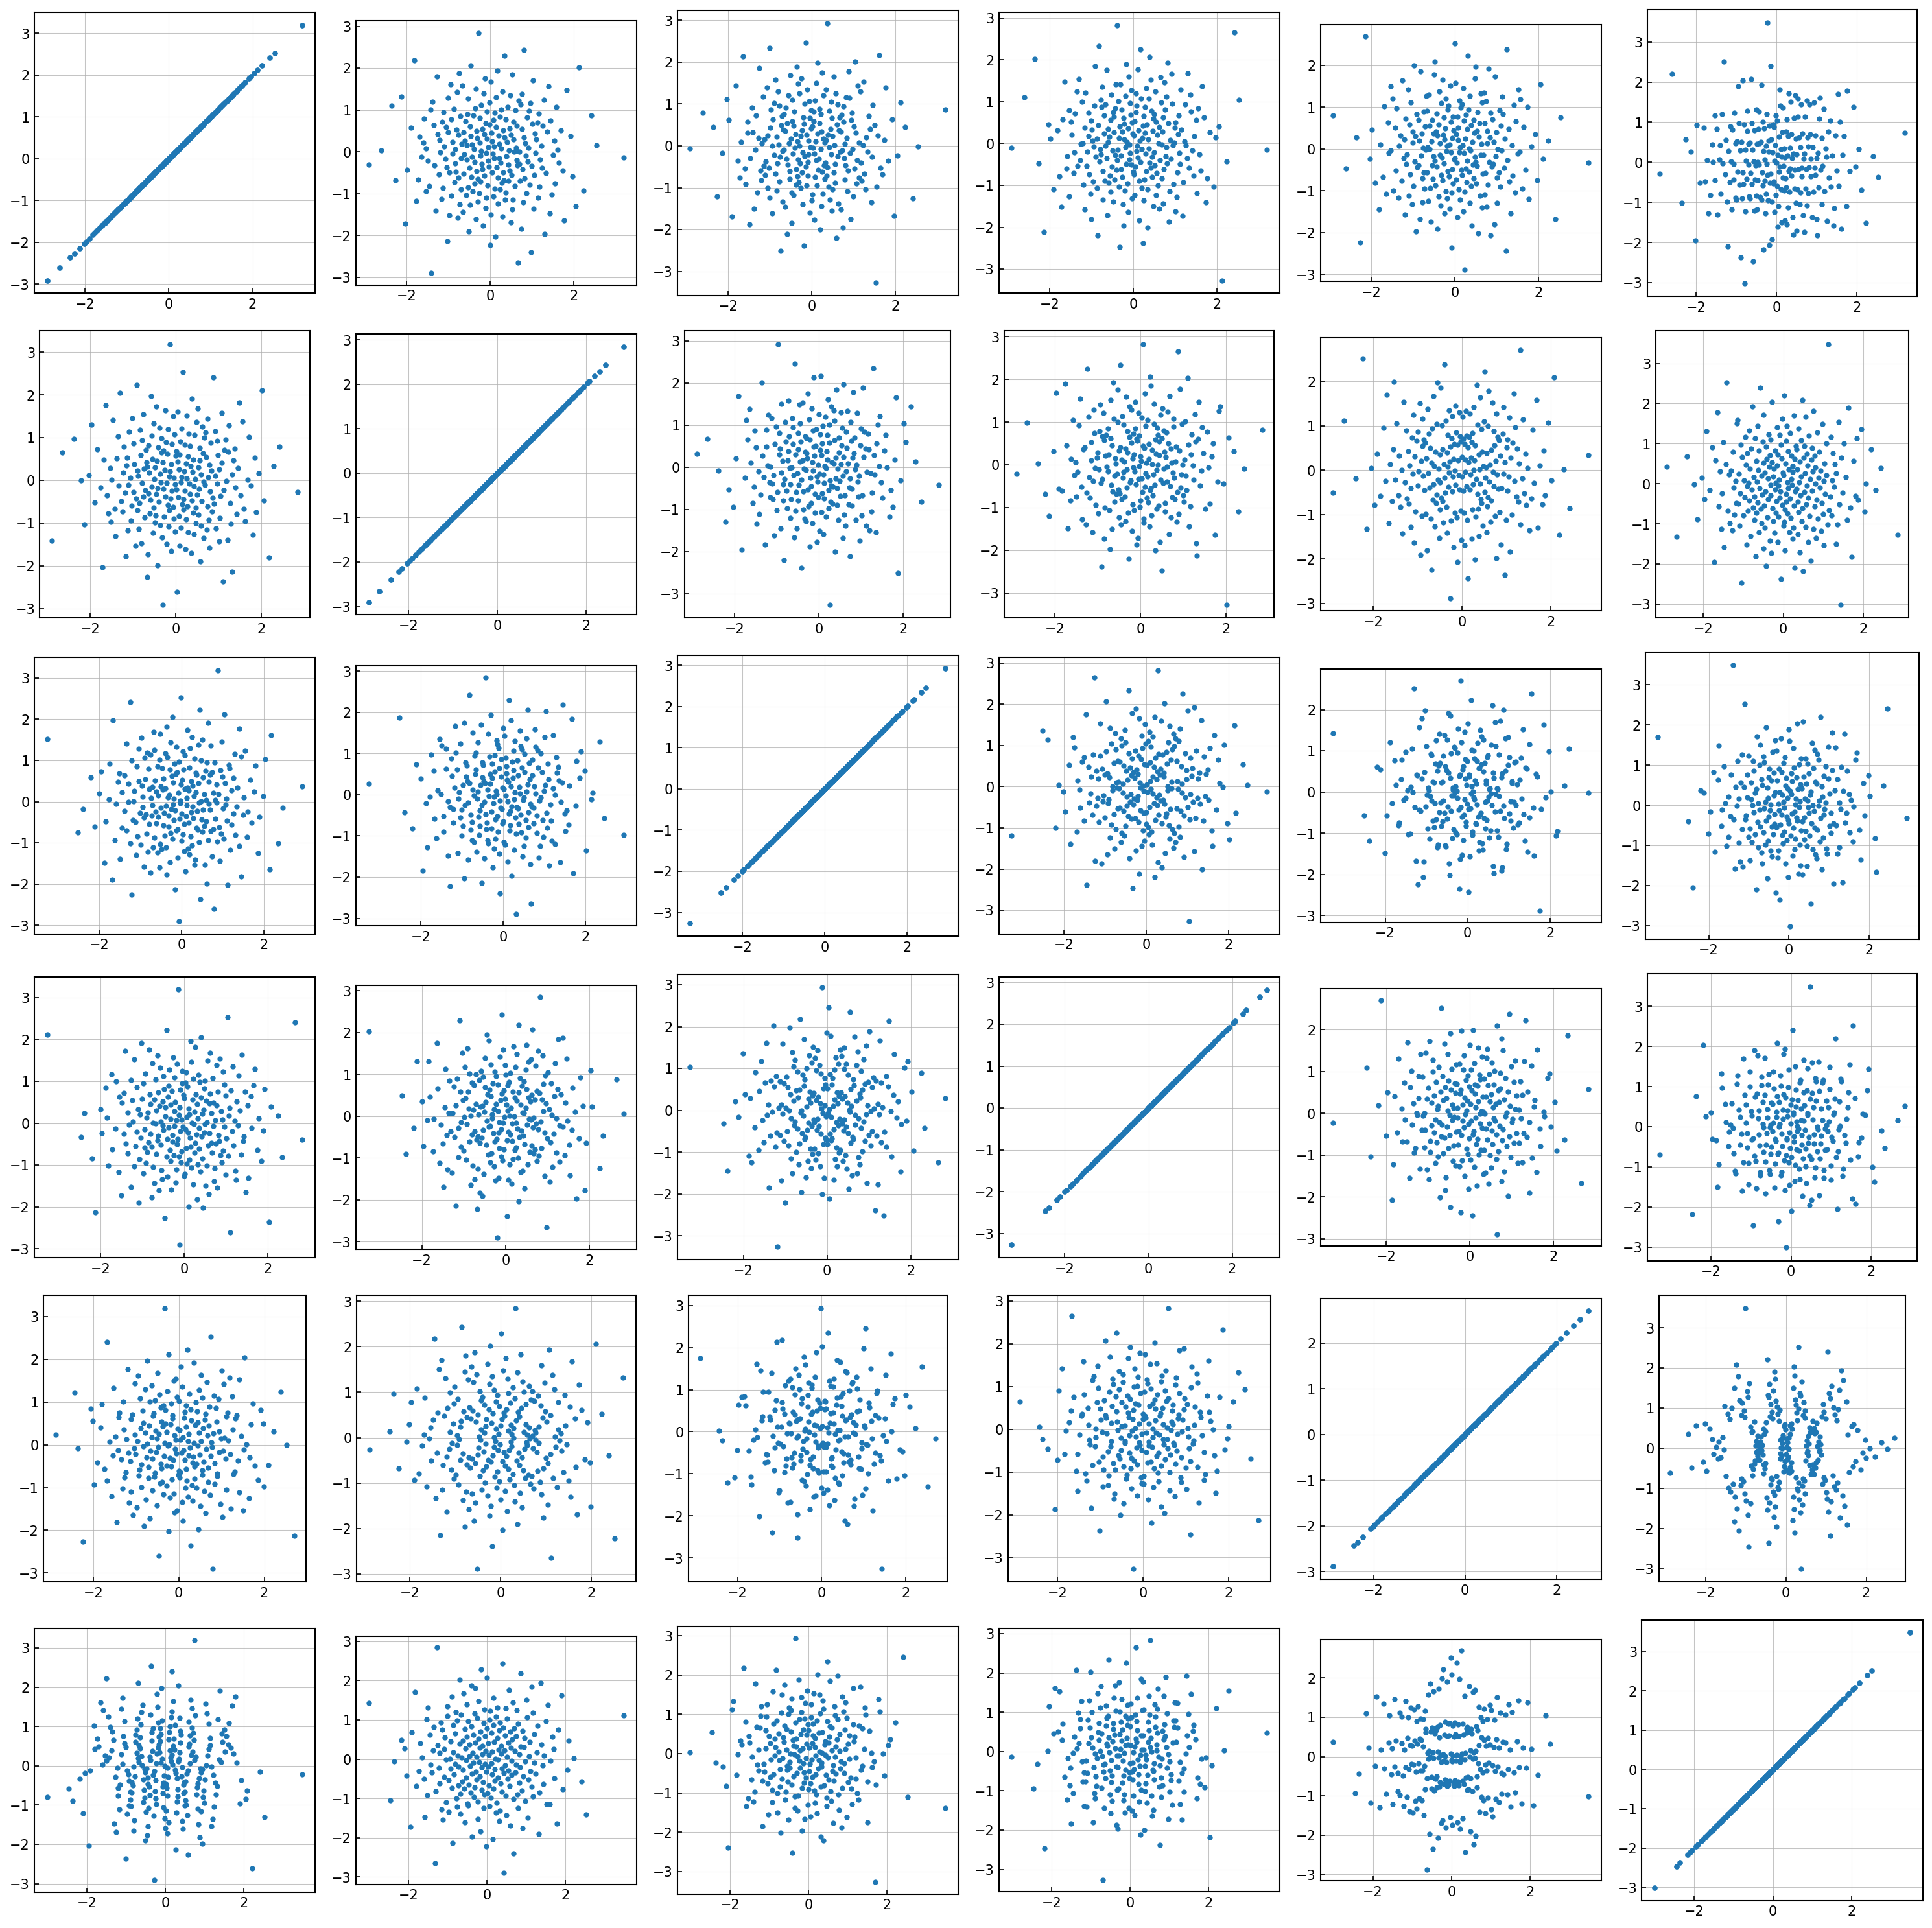

In [92]:
fig, axs = plt.subplots(6,6, figsize=[20,20])

for i in range(6):
    gsi = gaussian_samples[:,i]
    for j in range(i, 6):
        gsj = gaussian_samples[:,j]
        axs[i,j].plot(gsi, gsj, lw=0.0, marker='o', ms=3, color='tab:blue')
        axs[j,i].plot(gsj, gsi, lw=0.0, marker='o', ms=3, color='tab:blue')

 
        axkwargs = {
            # 'xticks': timevec[::10],
            # 'ylim': [-20, 20],
            # 'xlabel': 'Time [s]',
            # 'ylabel': 'velocity [m]',
            'aspect': 'equal',
        }

        axs[i,j].set(**axkwargs)
        axs[j,i].set(**axkwargs)
    
plt.tight_layout()
plt.show()

In [93]:
gaussian_samples.mean(axis=0)

array([ 0.0008431 , -0.00171777, -0.00153749, -0.00111727, -0.00036712,
        0.00198325])

In [94]:
gaussian_samples.std(axis=0)

array([1.00410977, 0.99778466, 1.00271895, 1.00248244, 0.99556134,
       1.00634257])